
Number of non-isomorphic trees on 8 vertices: 23

Rank  Tree ID        Energy
----------------------------
   1       22      5.291503
   2       21      6.774108
   3       18      7.115295
   4       11      7.211103
   5       14      7.211103
   6       12      7.384646
   7       20      8.152756
   8       13      8.261125
   9        7      8.312845
  10       17      8.375131
  11       15      8.424292
  12        2      8.472136
  13       10      8.519258
  14        4      8.565187
  15        8      8.647053
  16       16      8.720566
  17        1      8.762573
  18        6      8.828427
  19       19      9.291503
  20        5      9.331737
  21        3      9.409260
  22        9      9.445871
  23        0      9.517541

Lowest-energy tree:
Tree ID = 22, Energy = 5.291503

Highest-energy tree:
Tree ID = 0, Energy = 9.517541


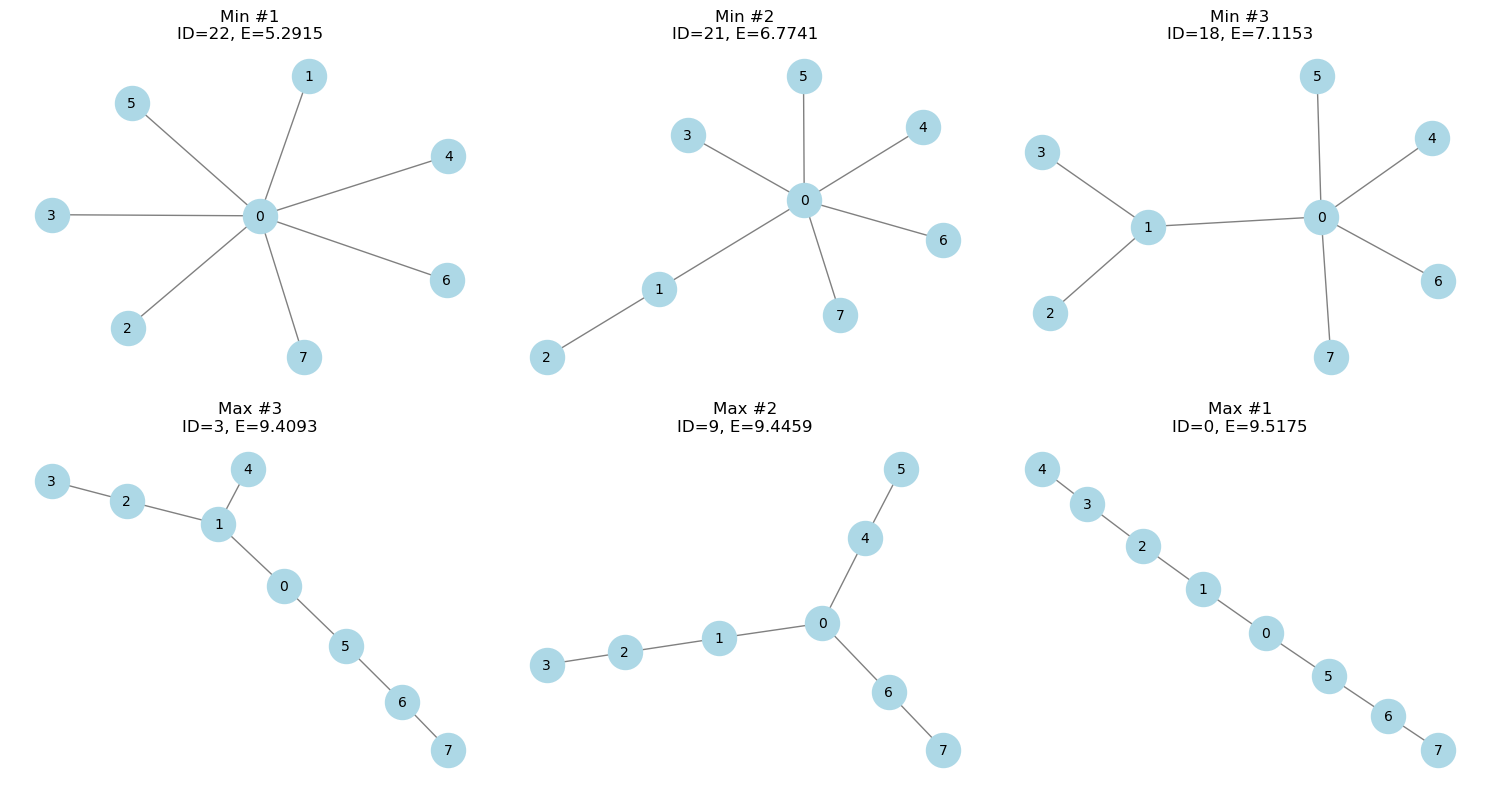

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


def graph_energy(G):
    """
    Compute the energy of a graph G:
        E(G) = sum of absolute values of adjacency eigenvalues.
    """
    A = nx.to_numpy_array(G)
    eigvals = np.linalg.eigvalsh(A)   # symmetric matrix -> real eigenvalues
    return float(np.sum(np.abs(eigvals)))


def all_trees_sorted_by_energy(n):
    """
    Generate all non-isomorphic trees on n vertices,
    compute their energies, and return them sorted by energy.
    """
    results = []

    for i, T in enumerate(nx.nonisomorphic_trees(n)):
        E = graph_energy(T)
        results.append((E, i, T.copy()))

    results.sort(key=lambda x: x[0])   # sort by energy
    return results


def print_energy_table(results, digits=6):
    """
    Print energies in sorted order.
    """
    print(f"{'Rank':>4}  {'Tree ID':>7}  {'Energy':>12}")
    print("-" * 28)
    for rank, (E, tree_id, _) in enumerate(results, start=1):
        print(f"{rank:>4}  {tree_id:>7}  {E:>12.{digits}f}")


def draw_selected_trees(results, how_many=6):
    """
    Draw the first few and last few trees in the sorted list.
    """
    total = len(results)
    if total == 0:
        return

    selected = []

    # smallest energies
    for i in range(min(how_many, total)):
        selected.append((f"Min #{i+1}", results[i]))

    # largest energies
    start = max(how_many, total - how_many)
    for i in range(start, total):
        selected.append((f"Max #{total - i}", results[i]))

    m = len(selected)
    cols = 3
    rows = (m + cols - 1) // cols

    plt.figure(figsize=(5 * cols, 4 * rows))

    for k, (label, (E, tree_id, T)) in enumerate(selected, start=1):
        plt.subplot(rows, cols, k)
        pos = nx.spring_layout(T, seed=42)
        nx.draw(
            T,
            pos,
            with_labels=True,
            node_color="lightblue",
            edge_color="gray",
            node_size=600,
            font_size=10,
        )
        plt.title(f"{label}\nID={tree_id}, E={E:.4f}")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    n = 8   # change this to any number of vertices you want

    results = all_trees_sorted_by_energy(n)

    print(f"\nNumber of non-isomorphic trees on {n} vertices: {len(results)}\n")
    print_energy_table(results)

    print("\nLowest-energy tree:")
    E_min, id_min, T_min = results[0]
    print(f"Tree ID = {id_min}, Energy = {E_min:.6f}")

    print("\nHighest-energy tree:")
    E_max, id_max, T_max = results[-1]
    print(f"Tree ID = {id_max}, Energy = {E_max:.6f}")

    draw_selected_trees(results, how_many=3)